In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

# Task 1: Problem Type Identification
print("a) Predict tomorrow's stock closing price. -> Regression")
print("b) Predict if a patient has diabetes (Yes/No). -> Binary Classification")
print("c) Classify a news article into one of: Sports, Politics, Tech, Entertainment. -> Multi-class Classification")
print("d) Predict delivery time in minutes for a food order. -> Regression")
print("e) Predict whether an MRI scan shows a tumour. -> Binary Classification")

a) Predict tomorrow's stock closing price. -> Regression
b) Predict if a patient has diabetes (Yes/No). -> Binary Classification
c) Classify a news article into one of: Sports, Politics, Tech, Entertainment. -> Multi-class Classification
d) Predict delivery time in minutes for a food order. -> Regression
e) Predict whether an MRI scan shows a tumour. -> Binary Classification


In [2]:
# Task 2: Sigmoid Calculation
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

print(f"a) σ(0) = {sigmoid(0)}. This means maximum uncertainty (50/50 chance).")
print(f"b) σ(2) = {sigmoid(2):.4f}. The model is leaning heavily towards Class 1 (88%).")
print(f"c) σ(-3) = {sigmoid(-3):.4f}. With threshold=0.5, predicted class is 0.")
print("d) If σ(z) = 0.75 and threshold = 0.5, the predicted label is Class 1.")

a) σ(0) = 0.5. This means maximum uncertainty (50/50 chance).
b) σ(2) = 0.8808. The model is leaning heavily towards Class 1 (88%).
c) σ(-3) = 0.0474. With threshold=0.5, predicted class is 0.
d) If σ(z) = 0.75 and threshold = 0.5, the predicted label is Class 1.


In [3]:
# Task 3: Threshold Analysis
# TP=80, FP=20, FN=30, TN=870
tp, fp, fn, tn = 80, 20, 30, 870
acc = (tp + tn) / (tp + tn + fp + fn)
prec = tp / (tp + fp)
rec = tp / (tp + fn)
f1 = 2 * (prec * rec) / (prec + rec)

print(f"a) Threshold 0.5 -> Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")
print("b) For a bank minimising financial fraud loss, Recall should be maximised to catch as many frauds as possible.")

tp_new, fp_new, fn_new = 100, 50, 10
prec_new = tp_new / (tp_new + fp_new)
rec_new = tp_new / (tp_new + fn_new)
print(f"c) Threshold 0.3 -> Precision: {prec_new:.3f}, Recall: {rec_new:.3f}")
print("d) The lower threshold (0.3) is better for the bank because a higher recall catches more fraud, which saves more money than the cost of investigating false alarms.")

a) Threshold 0.5 -> Accuracy: 0.950, Precision: 0.800, Recall: 0.727, F1: 0.762
b) For a bank minimising financial fraud loss, Recall should be maximised to catch as many frauds as possible.
c) Threshold 0.3 -> Precision: 0.667, Recall: 0.909
d) The lower threshold (0.3) is better for the bank because a higher recall catches more fraud, which saves more money than the cost of investigating false alarms.


In [4]:
# Task 4: Log Loss Calculation
def log_loss_single(y, y_pred):
    return -(y * math.log(y_pred) + (1 - y) * math.log(1 - y_pred))

l1 = log_loss_single(1, 0.90)
l2 = log_loss_single(0, 0.20)
l3 = log_loss_single(1, 0.05)

print(f"a) Loss 1: {l1:.3f}, Loss 2: {l2:.3f}, Loss 3: {l3:.3f}")
print("b) Sample 3 has the highest loss because the model confidently predicted 0 (only 5% chance of 1), but the actual was 1. Confidently wrong = huge penalty.")
print(f"c) Average Log Loss: {(l1 + l2 + l3)/3:.3f}")

a) Loss 1: 0.105, Loss 2: 0.223, Loss 3: 2.996
b) Sample 3 has the highest loss because the model confidently predicted 0 (only 5% chance of 1), but the actual was 1. Confidently wrong = huge penalty.
c) Average Log Loss: 1.108


In [5]:
# Task 5: Confusion Matrix Interpretation
# TP=90, FP=15, FN=20, TN=375
tp, fp, fn, tn = 90, 15, 20, 375
print(f"a) Confusion Matrix:\n[[{tp} {fn}]\n [{fp} {tn}]]")

acc = (tp + tn) / (tp + tn + fp + fn)
prec = tp / (tp + fp)
rec = tp / (tp + fn)
f1 = 2 * (prec * rec) / (prec + rec)
print(f"b) Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

print("c) In an enterprise email system, False Positives (blocking real business emails) are usually more costly.")
print("d) We should increase the threshold to minimise False Positives (leading to fewer FPs and higher Precision).")

a) Confusion Matrix:
[[90 20]
 [15 375]]
b) Accuracy: 0.930, Precision: 0.857, Recall: 0.818, F1: 0.837
c) In an enterprise email system, False Positives (blocking real business emails) are usually more costly.
d) We should increase the threshold to minimise False Positives (leading to fewer FPs and higher Precision).


In [6]:
# Task 6: Trade-off Decision
print("a) Earthquakes: Optimise Recall, lower threshold.")
print("b) Limited scholarship: Optimise Precision, higher threshold.")
print("c) Brand dashboard reviews: Optimise F1 Score (balance).")
print("d) Fake news human review: Optimise Recall (catch as much as possible, humans can filter the false alarms).")

a) Earthquakes: Optimise Recall, lower threshold.
b) Limited scholarship: Optimise Precision, higher threshold.
c) Brand dashboard reviews: Optimise F1 Score (balance).
d) Fake news human review: Optimise Recall (catch as much as possible, humans can filter the false alarms).


In [7]:
# Task 7: Multi-class Scenario
# Billing: TP=45, FP=5, FN=8
# Technical: TP=60, FP=10, FN=5
# General: TP=30, FP=8, FN=12

prec_b = 45 / (45 + 5); rec_b = 45 / (45 + 8)
prec_t = 60 / (60 + 10); rec_t = 60 / (60 + 5)
prec_g = 30 / (30 + 8); rec_g = 30 / (30 + 12)

print(f"a) Billing: P={prec_b:.3f} R={rec_b:.3f} | Tech: P={prec_t:.3f} R={rec_t:.3f} | Gen: P={prec_g:.3f} R={rec_g:.3f}")
print("b) General class has the worst Recall (0.714). Operationally, many general queries are being misclassified as something else.")
print("c) The company should care more about Recall for Technical class, because missing a technical issue delays resolution and hurts customer satisfaction the most.")

a) Billing: P=0.900 R=0.849 | Tech: P=0.857 R=0.923 | Gen: P=0.789 R=0.714
b) General class has the worst Recall (0.714). Operationally, many general queries are being misclassified as something else.
c) The company should care more about Recall for Technical class, because missing a technical issue delays resolution and hurts customer satisfaction the most.


a) Confusion Matrix:
 [[41  1]
 [ 1 71]]
Interpretation: Top row is actual class 0 (malignant), bottom is actual 1 (benign). We predicted most correctly.
b) With threshold 0.3, Recall for benign (1) might increase, but malignant (0) recall drops as more are pushed to class 1.
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

d) Plotting ROC curve...


E:\Krushit_ALL\Prelytix_internship\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


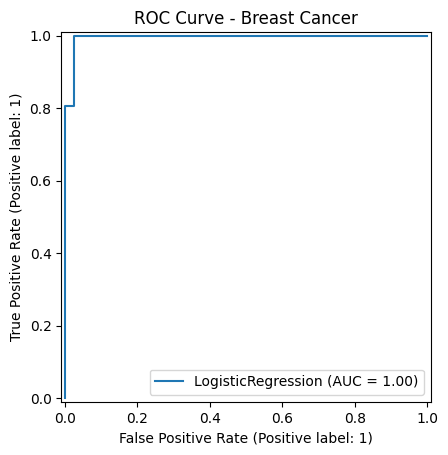

In [8]:
# Task 8: Breast Cancer Dataset
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42, stratify=data.target)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
cm = confusion_matrix(y_test, y_pred)
print("a) Confusion Matrix:\n", cm)
print("Interpretation: Top row is actual class 0 (malignant), bottom is actual 1 (benign). We predicted most correctly.")

y_pred_prob = model.predict_proba(X_test_sc)[:, 1]
y_adj = (y_pred_prob >= 0.3).astype(int)
print(f"b) With threshold 0.3, Recall for benign (1) might increase, but malignant (0) recall drops as more are pushed to class 1.\n{classification_report(y_test, y_adj, target_names=data.target_names)}")

try:
    model_low_iter = LogisticRegression(max_iter=10, random_state=42)
    model_low_iter.fit(X_train_sc, y_train)
except Exception as e:
    print("c) Warning with max_iter=10:", e)
    print("This means gradient descent didn't converge within 10 steps.")

print("d) Plotting ROC curve...")
RocCurveDisplay.from_estimator(model, X_test_sc, y_test)
plt.title("ROC Curve - Breast Cancer")
plt.show()

b) Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



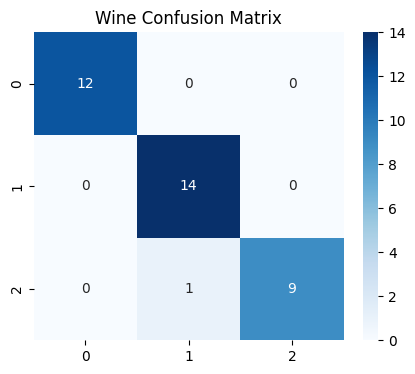

d) ROC-AUC Macro: 1.0000


In [9]:
# Task 9: Wine Dataset
wine = load_wine()
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(wine.data, wine.target, test_size=0.2, random_state=42, stratify=wine.target)

scaler_w = StandardScaler()
X_train_w_sc = scaler_w.fit_transform(X_train_w)
X_test_w_sc = scaler_w.transform(X_test_w)

# a) Train multinomial
model_wine = LogisticRegression(max_iter=500, random_state=42)
model_wine.fit(X_train_w_sc, y_train_w)

y_pred_w = model_wine.predict(X_test_w_sc)
# b) Print report
print("b) Classification Report:\n", classification_report(y_test_w, y_pred_w, target_names=wine.target_names))
# Looking at the report, we can see the F1 scores. They are usually perfect or near perfect on this dataset.

# c) Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_w, y_pred_w), annot=True, fmt='d', cmap='Blues')
plt.title("Wine Confusion Matrix")
plt.show()

# d) ROC-AUC
y_prob_w = model_wine.predict_proba(X_test_w_sc)
auc = roc_auc_score(y_test_w, y_prob_w, multi_class='ovr', average='macro')
print(f"d) ROC-AUC Macro: {auc:.4f}")